## Explicação do dataset criado

## Parâmentros de variáveis

In [1]:
!pip install truncnorm


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import truncnorm

PARAMS = {
    "n_alunos": 2000,
    "proporcao_evasao_geral": 0.10,
    "evasao_por_etapa": {
        "1° EF": 0.002, "2° EF": 0.001, "3° EF": 0.002, "4° EF": 0.002,
        "5° EF": 0.002, "6° EF": 0.01, "7° EF": 0.014, "8° EF": 0.012,
        "9° EF": 0.018, "1° EM": 0.04, "2° EM": 0.046, "3° EM": 0.03
    },

    "p_estudante_nis": 0.3,
    "p_informou_nome_mae": 0.95,
    "p_informou_nome_pai": 0.7,
    "p_possui_deficiencia": 0.05,
    "raca_cor_p": [0.35, 0.1, 0.45, 0.05, 0.02, 0.03],  # Branca, Preta, Parda, Amarela, Indígena, Não declarada
    "tipo_localizacao_p": [0.8, 0.2],  # Urbana, Rural
    "situacao_consolidada_p": [0.7, 0.15, 0.1, 0.05],  # Aprovado, Reprovado, Evadido, Em andamento
    "p_repetente": 0.047,
    "p_trabalha": 0.15,
    "p_trabalho_domestico_excessivo": 0.1,
    "p_problemas_de_saude": 0.1,
    "p_violencia_domestica": 0.05,
    "p_gravidez_na_adolescencia": 0.03,
    "p_necessita_assistencia_social": 0.3,
    "p_fator_desencadeador_presente": 0.1,
    "p_violencia_na_comunidade": 0.2,
    "apoio_familiar_p": [0.4, 0.4, 0.2],  # Alto, Médio, Baixo
    "comportamento_p": [0.5, 0.3, 0.2],  # Bom, Regular, Ruim
    "aceitacao_p": [0.5, 0.3, 0.2],
    "expectativa_p": [0.5, 0.3, 0.2],
    "engajamento_p": [0.4, 0.4, 0.2],
    "infraestrutura_p": [0.5, 0.3, 0.2],
    "material_p": [0.6, 0.3, 0.1],
    "flex_pedagogica_p": [0.4, 0.4, 0.2],
    "qualidade_pedagogica_p": [0.5, 0.3, 0.2],
    "random_seed": 42
}

random.seed(PARAMS["random_seed"])
np.random.seed(PARAMS["random_seed"])

etapas = ["1° EF", "2° EF", "3° EF", "4° EF", "5° EF", "6° EF",
          "7° EF", "8° EF", "9° EF", "1° EM", "2° EM", "3° EM"]

apoio_familiar_vals = ['Alto', 'Médio', 'Baixo']
comportamento_vals = ['Bom', 'Regular', 'Ruim']
aceitacao_vals = ['Alta', 'Média', 'Baixa']
expectativa_vals = ['Alta', 'Média', 'Baixa']
engajamento_vals = ['Alto', 'Moderado', 'Baixo']
infraestrutura_vals = ['Boa', 'Regular', 'Ruim']
material_vals = ['Completa', 'Parcial', 'Insuficiente']
flex_pedagogica_vals = ['Alta', 'Média', 'Baixa']
qualidade_pedagogica_vals = ['Boa', 'Regular', 'Ruim']
sexos = ['Masculino', 'Feminino', 'Outro']
raca_list = ['Branca', 'Preta', 'Parda', 'Amarela', 'Indígena', 'Não declarada']

## Funções de geração de variáveis

In [3]:
def escolher_por_prob(lista, probs):
    return np.random.choice(lista, p=probs)

def gerar_etapa_aleatoria():
    qtd_matriculas_etapas = np.array([28087, 29163, 33253, 28054, 28682, 29944,
                                      30364, 28886, 30368, 31195, 29372, 25056], dtype=float)
    distr = qtd_matriculas_etapas / qtd_matriculas_etapas.sum()
    return np.random.choice(etapas, p=distr)

def gerar_etapas(n):
    qtd_matriculas_etapas = np.array([28087, 29163, 33253, 28054, 28682, 29944,
                                      30364, 28886, 30368, 31195, 29372, 25056], dtype=float)
    distr = qtd_matriculas_etapas / qtd_matriculas_etapas.sum()
    return list(np.random.choice(etapas, size=n, p=distr))

def gerar_evasao_por_etapa(etapa):
    return PARAMS["evasao_por_etapa"].get(etapa, PARAMS["proporcao_evasao_geral"])

idades = list(range(6, 20))
pesos_idades = np.linspace(1, 0.5, len(idades))
pesos_idades_evadiu = np.linspace(0.3, 1, len(idades))

def gerar_idade(evadiu: bool):
    return random.choices(idades, weights=pesos_idades_evadiu if evadiu else pesos_idades)[0]

def gerar_sexo(evadiu: bool):
    return random.choices(sexos, weights=[0.48, 0.48, 0.04])[0]

def gerar_estudante_nis(evadiu: bool):
    return random.choices([True, False], weights=[0.45, 0.55] if evadiu else [PARAMS["p_estudante_nis"], 1-PARAMS["p_estudante_nis"]])[0]

def gerar_informou_nome_mae(evadiu: bool):
    return random.choices([True, False], weights=[0.9, 0.1] if evadiu else [PARAMS["p_informou_nome_mae"], 1-PARAMS["p_informou_nome_mae"]])[0]

def gerar_informou_nome_pai(evadiu: bool):
    return random.choices([True, False], weights=[0.6, 0.4] if evadiu else [PARAMS["p_informou_nome_pai"], 1-PARAMS["p_informou_nome_pai"]])[0]

def gerar_possui_deficiencia(evadiu: bool):
    return random.choices([True, False], weights=[0.08, 0.92] if evadiu else [PARAMS["p_possui_deficiencia"], 1-PARAMS["p_possui_deficiencia"]])[0]

def gerar_raca(evadiu: bool):
    pesos_evadiu = [0.25, 0.15, 0.45, 0.03, 0.02, 0.1]
    return random.choices(raca_list, weights=pesos_evadiu if evadiu else PARAMS["raca_cor_p"])[0]

def gerar_tipo_localizacao(evadiu: bool):
    return random.choices(['Urbana', 'Rural'], weights=[0.7, 0.3] if evadiu else PARAMS["tipo_localizacao_p"])[0]

def gerar_situacao_consolidada(evadiu: bool):
    if evadiu:
        return 'Evadido'
    return random.choices(['Aprovado', 'Reprovado', 'Evadido', 'Em andamento'], weights=PARAMS["situacao_consolidada_p"])[0]

def gerar_repetente(evadiu: bool):
    return random.choices([True, False], weights=[0.2, 0.8] if evadiu else [PARAMS["p_repetente"], 1-PARAMS["p_repetente"]])[0]

def gerar_frequencia(evadiu: bool):
    media = 75 if evadiu else 90
    desvio = 10
    a, b = (0 - media) / desvio, (100 - media) / desvio
    return round(truncnorm.rvs(a, b, loc=media, scale=desvio), 1)

def gerar_nota(evadiu: bool):
    if evadiu:
        distribuicao = {(0, 5): 0.45, (5, 7): 0.40, (7, 10): 0.15}
    else:
        distribuicao = {(0, 5): 0.2, (5, 7): 0.35, (7, 10): 0.45}
    faixas = list(distribuicao.keys())
    probs = list(distribuicao.values())
    faixa_escolhida = faixas[np.random.choice(len(faixas), p=probs)]
    nota = np.random.uniform(faixa_escolhida[0], faixa_escolhida[1])
    return round(nota, 1)

def gerar_nivel_socioeconomico(evadiu: bool):
    niveis = ["Muito baixo", "Baixo", "Médio", "Alto", "Muito alto"]
    pesos_evadiu = [0.3, 0.4, 0.25, 0.04, 0.01]
    return random.choices(niveis, weights=pesos_evadiu if evadiu else [0.1,0.3,0.4,0.15,0.05])[0]

def gerar_renda(evadiu: bool):
    if evadiu:
        faixa = (0,3)
    else:
        faixa = (1,8)
    salario_min = 1139.4
    renda_sm = np.random.uniform(*faixa)
    renda_reais = renda_sm * salario_min
    return round(renda_reais, 2)

def gerar_distancia(evadiu: bool):
    media = 3 if evadiu else 2
    return round(abs(np.random.normal(media, 1)), 1)

def gerar_trabalha(evadiu: bool):
    return random.choices([True, False], weights=[0.25, 0.75] if evadiu else [PARAMS["p_trabalha"], 1-PARAMS["p_trabalha"]])[0]

def gerar_trabalho_domestico_excessivo(evadiu: bool):
    return random.choices([True, False], weights=[0.18, 0.82] if evadiu else [PARAMS["p_trabalho_domestico_excessivo"], 1-PARAMS["p_trabalho_domestico_excessivo"]])[0]

def gerar_problemas_de_saude(evadiu: bool):
    return random.choices([True, False], weights=[0.15, 0.85] if evadiu else [PARAMS["p_problemas_de_saude"], 1-PARAMS["p_problemas_de_saude"]])[0]

def gerar_violencia_domestica(evadiu: bool):
    return random.choices([True, False], weights=[0.12, 0.88] if evadiu else [PARAMS["p_violencia_domestica"], 1-PARAMS["p_violencia_domestica"]])[0]

def gerar_gravidez_na_adolescencia(evadiu: bool):
    return random.choices([True, False], weights=[0.08, 0.92] if evadiu else [PARAMS["p_gravidez_na_adolescencia"], 1-PARAMS["p_gravidez_na_adolescencia"]])[0]

def gerar_apoio_familiar(evadiu: bool):
    pesos_evadiu = [0.25, 0.45, 0.3]
    return random.choices(apoio_familiar_vals, weights=pesos_evadiu if evadiu else PARAMS["apoio_familiar_p"])[0]

def gerar_comportamento(evadiu: bool):
    pesos_evadiu = [0.3, 0.4, 0.3]
    return random.choices(comportamento_vals, weights=pesos_evadiu if evadiu else PARAMS["comportamento_p"])[0]

def gerar_aceitacao_pares(evadiu: bool):
    pesos_evadiu = [0.4, 0.35, 0.25]
    return random.choices(aceitacao_vals, weights=pesos_evadiu if evadiu else PARAMS["aceitacao_p"])[0]

def gerar_necessita_assistencia_social(evadiu: bool):
    return random.choices([True, False], weights=[0.45, 0.55] if evadiu else [PARAMS["p_necessita_assistencia_social"], 1-PARAMS["p_necessita_assistencia_social"]])[0]

def gerar_expectativa_retorno(evadiu: bool):
    pesos_evadiu = [0.3, 0.4, 0.3]
    return random.choices(expectativa_vals, weights=pesos_evadiu if evadiu else PARAMS["expectativa_p"])[0]

def gerar_fator_desencadeador_presente(evadiu: bool):
    return random.choices([True, False], weights=[0.2, 0.8] if evadiu else [PARAMS["p_fator_desencadeador_presente"], 1-PARAMS["p_fator_desencadeador_presente"]])[0]

def gerar_violencia_na_comunidade(evadiu: bool):
    return random.choices([True, False], weights=[0.3, 0.7] if evadiu else [PARAMS["p_violencia_na_comunidade"], 1-PARAMS["p_violencia_na_comunidade"]])[0]

def gerar_engajamento(evadiu: bool):
    pesos_evadiu = [0.25, 0.4, 0.35]
    return random.choices(engajamento_vals, weights=pesos_evadiu if evadiu else PARAMS["engajamento_p"])[0]

def gerar_infraestrutura(evadiu: bool):
    pesos_evadiu = [0.35, 0.4, 0.25]
    return random.choices(infraestrutura_vals, weights=pesos_evadiu if evadiu else PARAMS["infraestrutura_p"])[0]

def gerar_material(evadiu: bool):
    pesos_evadiu = [0.45, 0.35, 0.2]
    return random.choices(material_vals, weights=pesos_evadiu if evadiu else PARAMS["material_p"])[0]

def gerar_flex_pedagogica(evadiu: bool):
    pesos_evadiu = [0.25, 0.45, 0.3]
    return random.choices(flex_pedagogica_vals, weights=pesos_evadiu if evadiu else PARAMS["flex_pedagogica_p"])[0]

def gerar_qualidade_pedagogica(evadiu: bool):
    pesos_evadiu = [0.35, 0.4, 0.25]
    return random.choices(qualidade_pedagogica_vals, weights=pesos_evadiu if evadiu else PARAMS["qualidade_pedagogica_p"])[0]

In [4]:
## Geração

n_alunos = PARAMS["n_alunos"]

etapa_series = gerar_etapas(n_alunos)

serie_evasao = []
for etapa in etapa_series:
    p = gerar_evasao_por_etapa(etapa)
    serie_evasao.append(random.random() < p)

df = pd.DataFrame({
    'id_aluno': np.arange(1, n_alunos + 1),
    'etapa_ensino': etapa_series,
    'evasao': serie_evasao,
})

df['sexo'] = [gerar_sexo(e) for e in df['evasao']]
df['idade'] = [gerar_idade(e) for e in df['evasao']]
df['estudante_nis'] = [gerar_estudante_nis(e) for e in df['evasao']]
df['informou_nome_mae'] = [gerar_informou_nome_mae(e) for e in df['evasao']]
df['informou_nome_pai'] = [gerar_informou_nome_pai(e) for e in df['evasao']]
df['possui_deficiencia'] = [gerar_possui_deficiencia(e) for e in df['evasao']]
df['raca_cor'] = [gerar_raca(e) for e in df['evasao']]
df['tipo_localizacao_endereco_estudante'] = [gerar_tipo_localizacao(e) for e in df['evasao']]
df['situacao_consolidada_no_ano'] = [gerar_situacao_consolidada(e) for e in df['evasao']]
df['repetente'] = [gerar_repetente(e) for e in df['evasao']]
df['frequencia_escolar'] = [gerar_frequencia(e) for e in df['evasao']]
df['notas_medias'] = [gerar_nota(e) for e in df['evasao']]
df['nivel_socioeconomico'] = [gerar_nivel_socioeconomico(e) for e in df['evasao']]
df['renda_familiar'] = [gerar_renda(e) for e in df['evasao']]
df['distancia_da_escola_km'] = [gerar_distancia(e) for e in df['evasao']]
df['trabalha'] = [gerar_trabalha(e) for e in df['evasao']]
df['trabalho_domestico_excessivo'] = [gerar_trabalho_domestico_excessivo(e) for e in df['evasao']]
df['problemas_de_saude'] = [gerar_problemas_de_saude(e) for e in df['evasao']]
df['violencia_domestica'] = [gerar_violencia_domestica(e) for e in df['evasao']]
df['gravidez_na_adolescencia'] = [gerar_gravidez_na_adolescencia(e) for e in df['evasao']]
df['apoio_familiar'] = [gerar_apoio_familiar(e) for e in df['evasao']]
df['comportamento_em_sala'] = [gerar_comportamento(e) for e in df['evasao']]
df['aceitacao_pelos_pares'] = [gerar_aceitacao_pares(e) for e in df['evasao']]
df['necessita_assistencia_social'] = [gerar_necessita_assistencia_social(e) for e in df['evasao']]
df['expectativa_retorno'] = [gerar_expectativa_retorno(e) for e in df['evasao']]
df['fator_desencadeador_presente'] = [gerar_fator_desencadeador_presente(e) for e in df['evasao']]
df['violencia_na_comunidade'] = [gerar_violencia_na_comunidade(e) for e in df['evasao']]
df['engajamento_com_a_escola'] = [gerar_engajamento(e) for e in df['evasao']]
df['infraestrutura_escolar'] = [gerar_infraestrutura(e) for e in df['evasao']]
df['disponibilidade_material_didatico'] = [gerar_material(e) for e in df['evasao']]
df['flexibilidade_pedagogica'] = [gerar_flex_pedagogica(e) for e in df['evasao']]
df['qualidade_pedagogica_percebida'] = [gerar_qualidade_pedagogica(e) for e in df['evasao']]

df['pontuacao_risco'] = (
     (100 - df['frequencia_escolar']) / 100 * 0.3 +
     (10 - df['notas_medias']) / 10 * 0.3 +
     df['repetente'].astype(int) * 0.1 +
     df['trabalha'].astype(int) * 0.1 +
     df['violencia_domestica'].astype(int) * 0.2
)
df['pontuacao_risco'] = df['pontuacao_risco'] / df['pontuacao_risco'].max()
df['evasao_confirmada'] = [np.random.rand() < r for r in df['pontuacao_risco']]


csv_path = "./dataset_evasao_sintetico_v2.csv"
df.to_csv(csv_path, index=False)



## Análise Exploratória

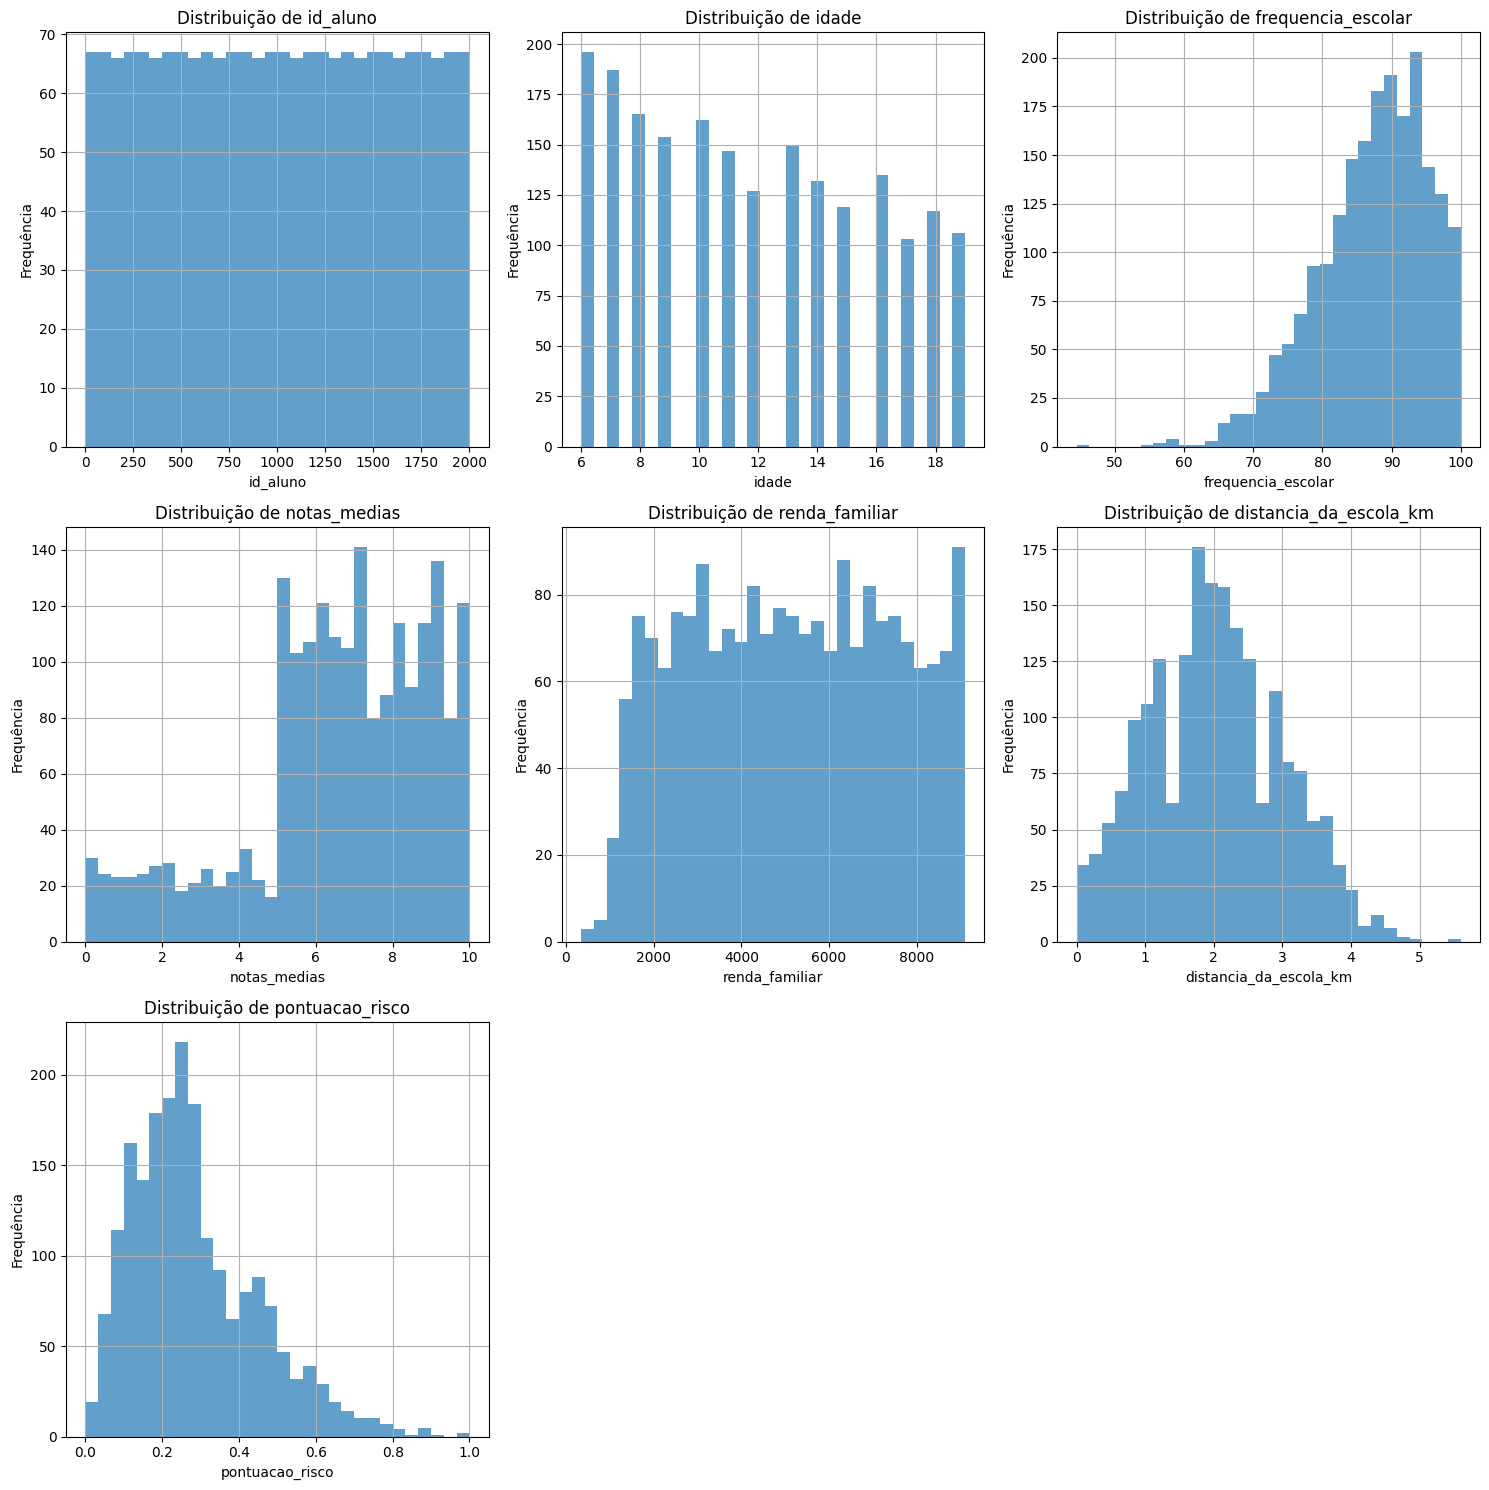

========== Var. Categóricas ==========


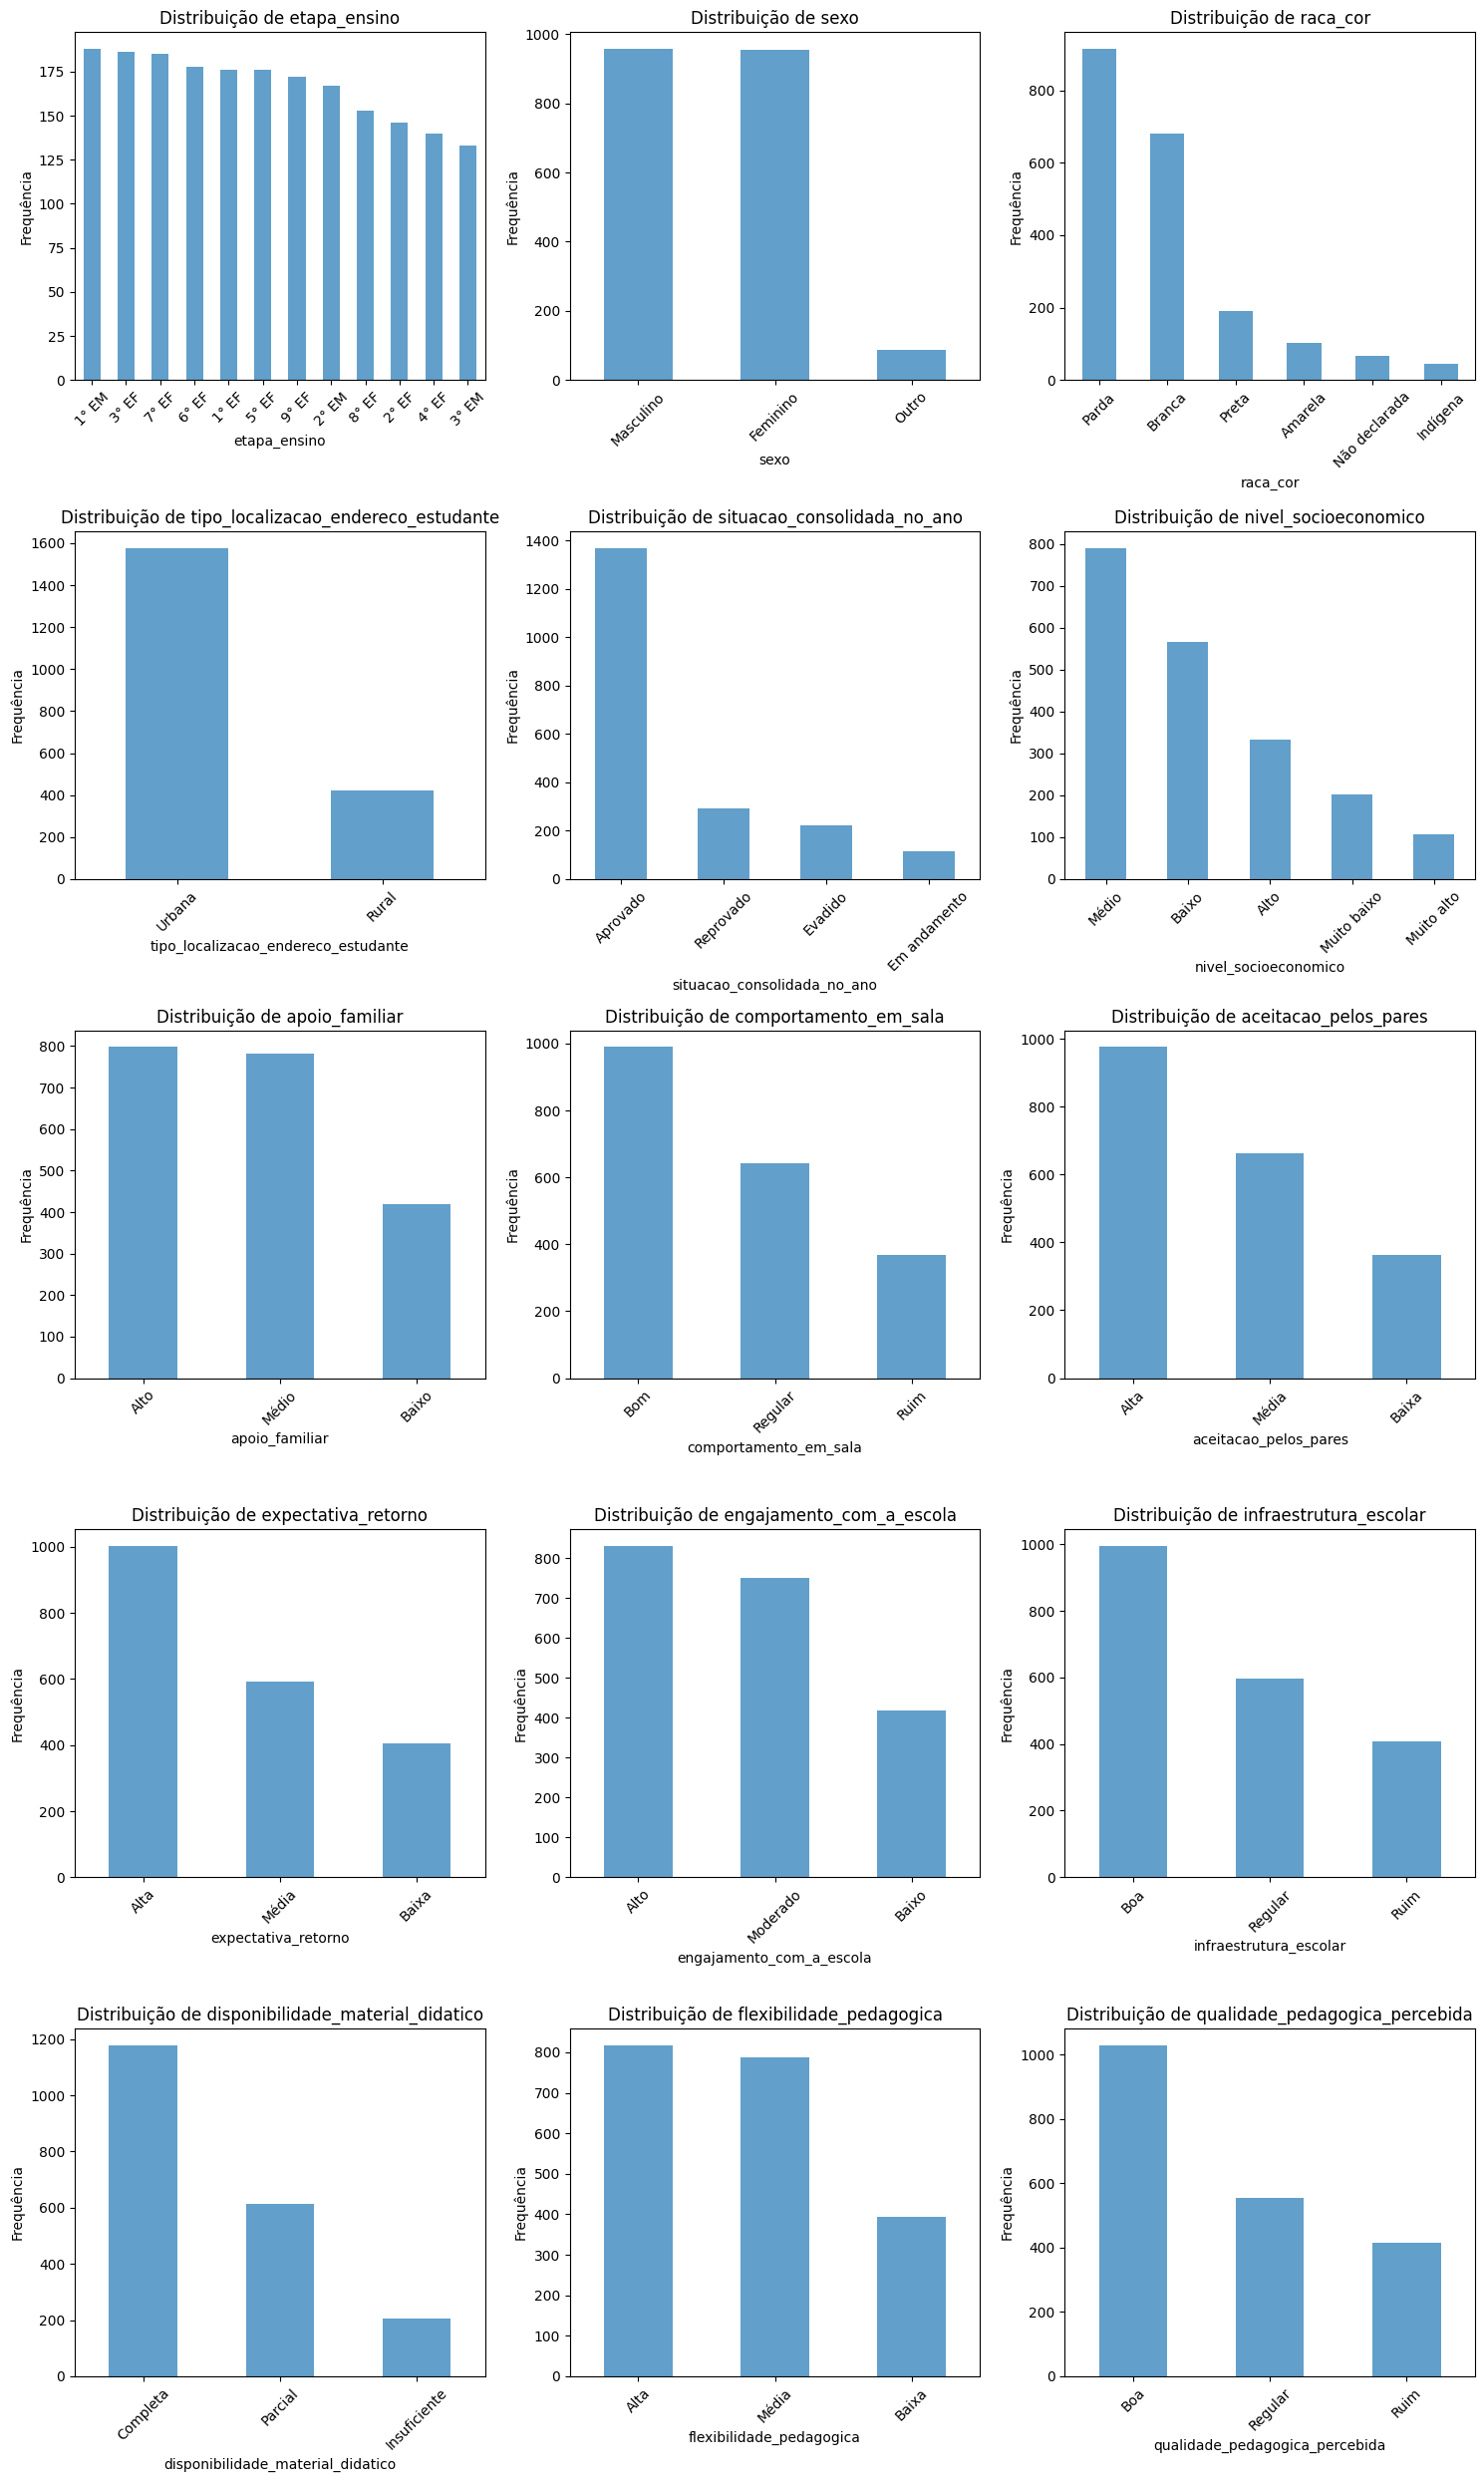

In [8]:
def plot_numerical_distributions(df):
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = len(numerical_cols)
    n_rows = (n_cols + 2) // 3  # 3 colunas por linha
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(numerical_cols):
        df[col].hist(bins=30, ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribuição de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequência')
    
    # Remover subplots vazios
    for i in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

# Para variáveis categóricas (gráficos de barras)
def plot_categorical_distributions(df):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    n_cols = len(categorical_cols)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(categorical_cols):
        df[col].value_counts().plot(kind='bar', ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribuição de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequência')
        axes[i].tick_params(axis='x', rotation=45)
    
    for i in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

# Uso
plot_numerical_distributions(df)
print("="*10 + " Var. Categóricas " + "="*10)
plot_categorical_distributions(df)